# notebook 03 — Random Forest
**Role:** Ensemble ML baseline  
**Data:** `Final_Cleaned_1m.parquet`  
**Features:** `total_traffic`, `avg_node_stress`, `replica_count`, `avg_response_time`  
**Target:** `total_cpu_demand`  
**Pipeline:** identical to LSTM — every-4th val split, log1p + MinMaxScaler  
**Metrics:** R², MAE, RMSE, MAPE → `results/all_models_results.csv`

In [1]:
import random, os, warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_PATH    = str(PROJECT_ROOT / 'cleanData' / 'Final_Cleaned_1m.parquet')
PLOTS_DIR    = str(PROJECT_ROOT / 'plots')
RESULTS_CSV  = str(PROJECT_ROOT / 'results' / 'all_models_results.csv')
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(str(PROJECT_ROOT / 'results'), exist_ok=True)

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})

def save_result(model_name, r2, mae, rmse, mape):
    row = pd.DataFrame([{'model':model_name,'R2':round(float(r2),4),
        'MAE':round(float(mae),4),'RMSE':round(float(rmse),4),'MAPE':round(float(mape),2)}])
    if os.path.exists(RESULTS_CSV):
        ex = pd.read_csv(RESULTS_CSV)
        row = pd.concat([ex[ex['model']!=model_name], row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"  Saved \u2192 results/all_models_results.csv")

print(f"Project root : {PROJECT_ROOT}")
print(f"Data         : {DATA_PATH}")


Project root : C:\Users\phone\Documents\Alibaba\Cloud_Autoscale
Data         : C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\cleanData\Final_Cleaned_1m.parquet


## 1. Load Data

In [2]:
print("Loading Cleaned 1-Minute Data...")
df_final_1m = pl.read_parquet(DATA_PATH)
print(f"Loaded Shape: {df_final_1m.shape}")
print(f"Columns: {df_final_1m.columns}")
print(f"Timestamp range: {df_final_1m['timestamp'].min()} to {df_final_1m['timestamp'].max()}")
print(f"Unique services: {df_final_1m['msname'].n_unique()}")


Loading Cleaned 1-Minute Data...
Loaded Shape: (937986, 8)
Columns: ['msname', 'timestamp', 'total_cpu_demand', 'total_memory_demand', 'total_traffic', 'avg_node_stress', 'avg_response_time', 'replica_count']
Timestamp range: 0 to 43140000
Unique services: 1303


## 2. Build Sliding Windows

In [3]:
print("Building sliding windows...")

WINDOW_SIZE   = 5
PREDICT_STEPS = 1
FEATURES = ['total_traffic','avg_node_stress','replica_count','avg_response_time']

X_raw, y_raw = [], []
for name, group in df_final_1m.sort('timestamp').group_by('msname'):
    group   = group.with_columns(pl.col('avg_response_time').fill_null(0))
    X_array = group.select(FEATURES).to_numpy()
    y_array = group.select('total_cpu_demand').to_numpy()
    for i in range(WINDOW_SIZE, len(X_array) - PREDICT_STEPS + 1):
        X_raw.append(X_array[i-WINDOW_SIZE:i, :])
        y_raw.append(y_array[i:i+PREDICT_STEPS, 0])

X_raw = np.array(X_raw)
y_raw = np.array(y_raw).reshape(-1, PREDICT_STEPS)
print(f"X_raw Shape: {X_raw.shape}  ({WINDOW_SIZE} timesteps x {len(FEATURES)} features)")
print(f"y_raw Shape: {y_raw.shape}")
print(f"y_raw max:   {y_raw.max():.4f} cores | mean: {y_raw.mean():.4f} cores")


Building sliding windows...
X_raw Shape: (931471, 5, 4)  (5 timesteps x 4 features)
y_raw Shape: (931471, 1)
y_raw max:   1712.0461 cores | mean: 13.9350 cores


## 3. Split & Scale 

In [4]:
print("Splitting into Train/Validation sets...")
val_indices   = np.arange(0, len(X_raw), 4)
train_indices = np.setdiff1d(np.arange(len(X_raw)), val_indices)

X_train_raw = X_raw[train_indices];  X_val_raw = X_raw[val_indices]
y_train_raw = y_raw[train_indices];  y_val_raw = y_raw[val_indices]
print(f"X_train: {X_train_raw.shape} | X_val: {X_val_raw.shape}")
print(f"y_train: {y_train_raw.shape} | y_val: {y_val_raw.shape}")

print("\nScaling with Log Transform...")
n_train, timesteps, n_features = X_train_raw.shape

y_train_log = np.log1p(y_train_raw);  y_val_log = np.log1p(y_val_raw)
X_train_log = np.log1p(X_train_raw);  X_val_log = np.log1p(X_val_raw)

X_scaler = MinMaxScaler()
X_train_scaled = X_scaler.fit_transform(
    X_train_log.reshape(-1, n_features)).reshape(n_train, timesteps, n_features)
X_val_scaled   = X_scaler.transform(
    X_val_log.reshape(-1, n_features)).reshape(X_val_log.shape)

y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train_log)
y_val_scaled   = y_scaler.transform(y_val_log)

# Flatten 3D -> 2D for sklearn, keep y as 1D
X_train_2d = X_train_scaled.reshape(n_train, -1)
X_val_2d   = X_val_scaled.reshape(len(X_val_scaled), -1)
y_train_1d = y_train_scaled.flatten()

print(f"\nX_train_2d: {X_train_2d.shape} | X_val_2d: {X_val_2d.shape}")
print(f"y_scaler range: {y_scaler.data_min_[0]:.4f} to {y_scaler.data_max_[0]:.4f} (log scale)")
print(f"Evaluated on val: {X_val_2d.shape[0]:,} samples")


Splitting into Train/Validation sets...
X_train: (698603, 5, 4) | X_val: (232868, 5, 4)
y_train: (698603, 1) | y_val: (232868, 1)

Scaling with Log Transform...

X_train_2d: (698603, 20) | X_val_2d: (232868, 20)
y_scaler range: 0.0000 to 7.4460 (log scale)
Evaluated on val: 232,868 samples


## 4. Hyperparameter Search

In [5]:
from sklearn.ensemble import RandomForestRegressor

configs = [
    {'n_estimators': 50,  'max_depth': 5},
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': 15},
    {'n_estimators': 200, 'max_depth': None},
]
rf_res = {}
for cfg in configs:
    name = f"RF n={cfg['n_estimators']} d={cfg['max_depth']}"
    print(f"Training {name}...")
    m = RandomForestRegressor(**cfg, random_state=SEED, n_jobs=-1)
    m.fit(X_train_2d, y_train_1d)
    pred_scaled = m.predict(X_val_2d)
    pred_act = np.expm1(y_scaler.inverse_transform(pred_scaled.reshape(-1,1))).flatten()
    true_act = np.expm1(y_scaler.inverse_transform(y_val_scaled.reshape(-1,1))).flatten()
    r2_  = r2_score(true_act, pred_act)
    mae_ = mean_absolute_error(true_act, pred_act)
    rmse_= np.sqrt(mean_squared_error(true_act, pred_act))
    mape_= np.mean(np.abs((true_act-pred_act)/(true_act+1e-8)))*100
    rf_res[name] = {'pred_scaled':pred_scaled,'R2':r2_,'MAE':mae_,'RMSE':rmse_,'MAPE':mape_,'model':m}
    print(f"  R²={r2_:.4f} | MAE={mae_:.4f} | RMSE={rmse_:.4f} | MAPE={mape_:.2f}%")

best_name = min(rf_res, key=lambda k: rf_res[k]['RMSE'])
best = rf_res[best_name]
pred_scaled = best['pred_scaled']
best_model  = best['model']
r2, mae, rmse, mape = best['R2'], best['MAE'], best['RMSE'], best['MAPE']
print(f"\nBest config: {best_name}")
# Inverse: unscale log -> expm1 -> CPU cores (same as LSTM)
pred_actual = np.expm1(y_scaler.inverse_transform(pred_scaled.reshape(-1,1))).flatten()
true_actual = np.expm1(y_scaler.inverse_transform(y_val_scaled.reshape(-1,1))).flatten()

r2   = r2_score(true_actual, pred_actual)
mae  = mean_absolute_error(true_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(true_actual, pred_actual))
mape = np.mean(np.abs((true_actual - pred_actual) / (true_actual + 1e-8))) * 100

print()
print('=' * 40)
print('MODEL EVALUATION REPORT')
print('=' * 40)
print(f'MAE  (Mean Absolute Error):     {mae:.4f} cores')
print(f'RMSE (Root Mean Squared Error): {rmse:.4f} cores')
print(f'R\u00b2   (Explained Variance):      {r2:.4f}')
print(f'MAPE (Mean Absolute % Error):   {mape:.2f}%')
print(f'Evaluated on:                   {len(true_actual):,} samples')
print('=' * 40)
save_result('Random Forest', r2, mae, rmse, mape)

Training RF n=50 d=5...
  R²=0.9395 | MAE=4.1880 | RMSE=13.9293 | MAPE=4859.77%
Training RF n=100 d=10...
  R²=0.9930 | MAE=1.6964 | RMSE=4.7385 | MAPE=2374.97%
Training RF n=200 d=15...
  R²=0.9989 | MAE=0.5775 | RMSE=1.8798 | MAPE=1064.61%
Training RF n=200 d=None...
  R²=0.9994 | MAE=0.2977 | RMSE=1.3598 | MAPE=1047.64%

Best config: RF n=200 d=None

MODEL EVALUATION REPORT
MAE  (Mean Absolute Error):     0.2977 cores
RMSE (Root Mean Squared Error): 1.3598 cores
R²   (Explained Variance):      0.9994
MAPE (Mean Absolute % Error):   1047.64%
Evaluated on:                   232,868 samples
  Saved → results/all_models_results.csv


## 5. Plots

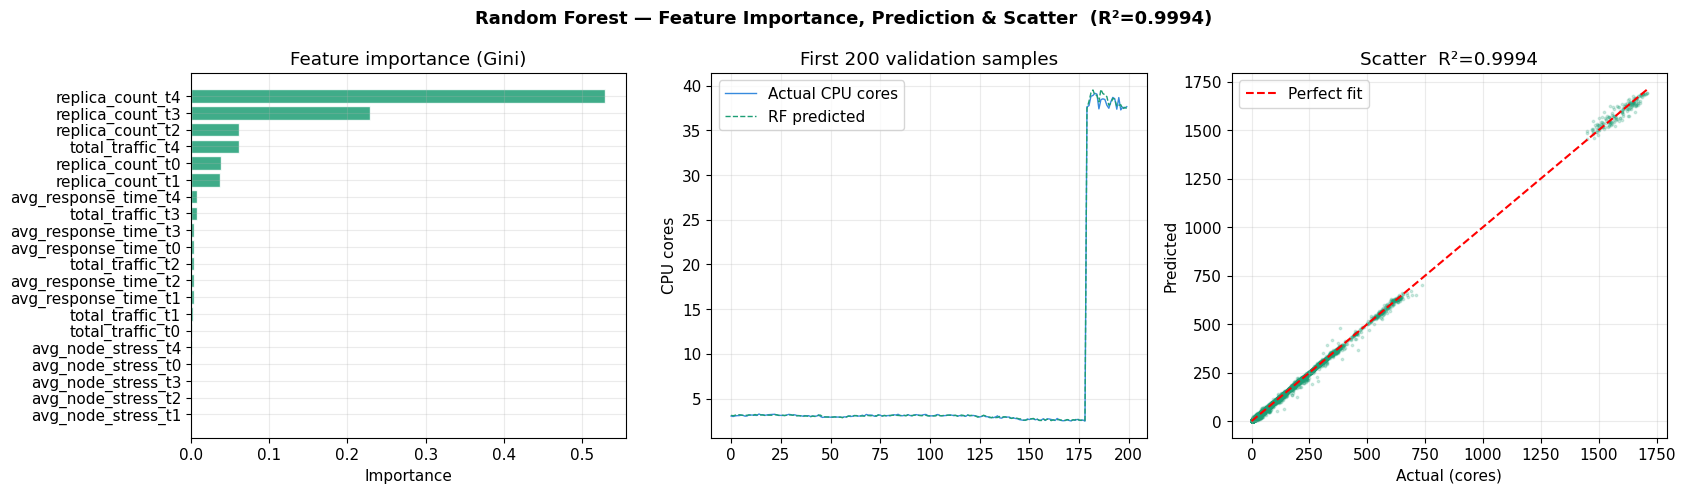

Saved: C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\plots\03_rf_results.png
Final — R²=0.9994 | MAE=0.2977 | RMSE=1.3598 | MAPE=1047.64%


In [6]:
feat_names  = [f"{f}_t{j}" for j in range(timesteps) for f in FEATURES]
importances = pd.Series(best_model.feature_importances_, index=feat_names).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'Random Forest — Feature Importance, Prediction & Scatter  (R²={r2:.4f})', fontsize=13, fontweight='bold')

axes[0].barh(importances.index, importances.values, color='#1D9E75', edgecolor='white', alpha=0.85)
axes[0].set_title('Feature importance (Gini)'); axes[0].set_xlabel('Importance')

n_show = min(200, len(true_actual))
axes[1].plot(true_actual[:n_show], color='#378ADD', linewidth=1.0, label='Actual CPU cores')
axes[1].plot(pred_actual[:n_show], color='#1D9E75', linewidth=1.0, linestyle='--', label='RF predicted')
axes[1].set_title(f'First {n_show} validation samples'); axes[1].set_ylabel('CPU cores'); axes[1].legend()

axes[2].scatter(true_actual, pred_actual, alpha=0.2, s=3, color='#1D9E75')
lims = [min(true_actual.min(), pred_actual.min()), max(true_actual.max(), pred_actual.max())]
axes[2].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[2].set_title(f'Scatter  R²={r2:.4f}'); axes[2].set_xlabel('Actual (cores)'); axes[2].set_ylabel('Predicted'); axes[2].legend()

for ax in axes: ax.grid(True, alpha=0.25)
plt.tight_layout()
out = os.path.join(PLOTS_DIR, '03_rf_results.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out}")
print(f"Final — R²={r2:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f} | MAPE={mape:.2f}%")
